## GAN Lab Assignment 1

Name: Madhusudan Hasbe\
PRN: 22070126061\
AIML A3

-------------

In [16]:
pip install torch matplotlib

Note: you may need to restart the kernel to use updated packages.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [18]:
# Generating sine wave data
def generate_sine_wave_data(seq_length, num_samples):
    x = np.linspace(0, 2 * np.pi, seq_length)
    data = [np.sin(x + np.random.uniform(0, 2 * np.pi)) for _ in range(num_samples)]
    return np.array(data)

In [19]:
# Parameters
seq_length = 50
num_samples = 2000
batch_size = 64
latent_dim = 10
num_epochs = 1000
lr = 0.001

# Preparing data
sine_data = generate_sine_wave_data(seq_length, num_samples)
sine_data = torch.tensor(sine_data, dtype=torch.float32).unsqueeze(-1)
dataloader = DataLoader(TensorDataset(sine_data), batch_size=batch_size, shuffle=True)

In [20]:
# Defining Generator
class Generator(nn.Module):
    def __init__(self, latent_dim, seq_length):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, seq_length)
        )

    def forward(self, z):
        return self.model(z)

# Defining Discriminator
class Discriminator(nn.Module):
    def __init__(self, seq_length):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(seq_length, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [21]:
# Initializing models
generator = Generator(latent_dim, seq_length)
discriminator = Discriminator(seq_length)

# Loss and optimizers
criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=lr)
d_optimizer = optim.Adam(discriminator.parameters(), lr=lr)

In [22]:
# Training loop
for epoch in range(num_epochs):
    for real_samples, in dataloader:
        batch_size = real_samples.size(0)

        # Train Discriminator
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        outputs = discriminator(real_samples.squeeze(-1))
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, latent_dim)
        fake_samples = generator(z)
        outputs = discriminator(fake_samples.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        z = torch.randn(batch_size, latent_dim)
        fake_samples = generator(z)
        outputs = discriminator(fake_samples)
        g_loss = criterion(outputs, real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}] - D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

Epoch [20/1000] - D Loss: 0.0458, G Loss: 5.9537
Epoch [40/1000] - D Loss: 0.4910, G Loss: 2.0081
Epoch [60/1000] - D Loss: 0.4146, G Loss: 2.6014
Epoch [80/1000] - D Loss: 1.0209, G Loss: 2.2755
Epoch [100/1000] - D Loss: 0.3108, G Loss: 4.7117
Epoch [120/1000] - D Loss: 0.4863, G Loss: 3.5686
Epoch [140/1000] - D Loss: 0.4949, G Loss: 1.7467
Epoch [160/1000] - D Loss: 0.3921, G Loss: 1.7453
Epoch [180/1000] - D Loss: 0.4747, G Loss: 1.9238
Epoch [200/1000] - D Loss: 0.7262, G Loss: 1.5302
Epoch [220/1000] - D Loss: 0.7715, G Loss: 1.9081
Epoch [240/1000] - D Loss: 1.4884, G Loss: 1.4751
Epoch [260/1000] - D Loss: 0.4622, G Loss: 2.1757
Epoch [280/1000] - D Loss: 0.6391, G Loss: 1.5810
Epoch [300/1000] - D Loss: 0.9966, G Loss: 1.7629
Epoch [320/1000] - D Loss: 0.5702, G Loss: 3.4739
Epoch [340/1000] - D Loss: 1.2204, G Loss: 1.4267
Epoch [360/1000] - D Loss: 0.8733, G Loss: 1.3615
Epoch [380/1000] - D Loss: 0.6733, G Loss: 1.9970
Epoch [400/1000] - D Loss: 0.6995, G Loss: 2.4617
Epoc

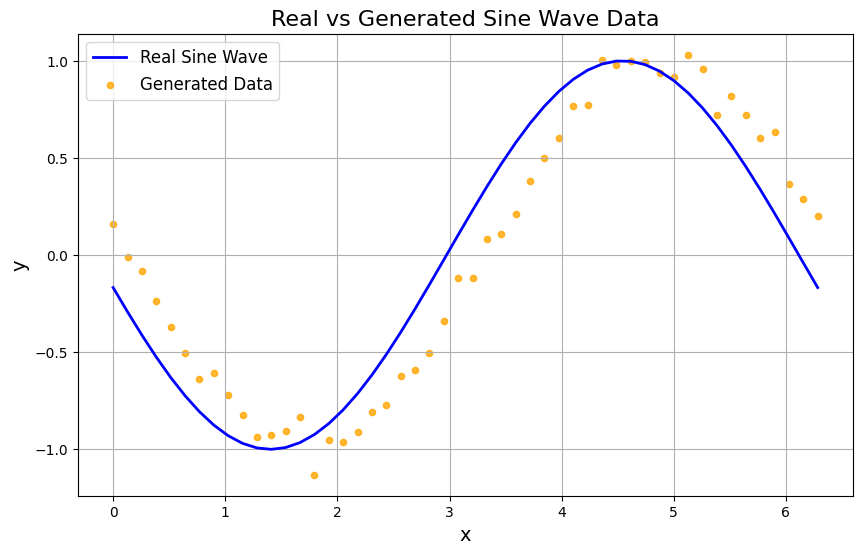

In [30]:
# Plotting the generated sine wave and original sine wave
z = torch.randn(1, latent_dim)
generated_sample = generator(z).detach().numpy()[0]
original_sample = sine_data[0].numpy().squeeze()

plt.figure(figsize=(10, 6))
x = np.linspace(0, 2 * np.pi, seq_length)
plt.plot(x, original_sample, label="Real Sine Wave", color="blue", linewidth=2)
plt.scatter(x, generated_sample, label="Generated Data", color="orange", s=20, alpha=0.8)
plt.title("Real vs Generated Sine Wave Data", fontsize=16)
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()